<a href="https://colab.research.google.com/github/jeyaraman357/ml-regression/blob/main/Laptop_Price_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Uploading the Dataset:**

In [ ]:
from google.colab import files
files.upload()


Saving laptop_data_cleaned.csv to laptop_data_cleaned.csv


{'laptop_data_cleaned.csv': b'Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os\r\nApple,Ultrabook,8,1.37,11.175754549129524,0,1,226.98300468106115,Intel Core i5,0,128,Intel,Mac\r\nApple,Ultrabook,8,1.34,10.77677731765335,0,0,127.67794013309688,Intel Core i5,0,0,Intel,Mac\r\nHP,Notebook,8,1.86,10.329931067029484,0,0,141.21199808219862,Intel Core i5,0,256,Intel,Others\r\nApple,Ultrabook,16,1.83,11.814475944954545,0,1,220.53462386625827,Intel Core i7,0,512,AMD,Mac\r\nApple,Ultrabook,8,1.37,11.473100972779063,0,1,226.98300468106115,Intel Core i5,0,256,Intel,Mac\r\nAcer,Notebook,4,2.1,9.967025573340116,0,0,100.45466986113651,AMD Processor,500,0,AMD,Windows\r\nApple,Ultrabook,16,2.04,11.64410811545818,0,1,220.53462386625827,Intel Core i7,0,0,Intel,Mac\r\nApple,Ultrabook,8,1.34,11.03061499223515,0,0,127.67794013309688,Intel Core i5,0,0,Intel,Mac\r\nAsus,Ultrabook,16,1.3,11.285442512056921,0,0,157.3505121487356,Intel Core i7,0,512,Nvidia,Windows\r\nAcer,Ultr

**Loading the dataset:**

In [ ]:
import pandas as pd
df = pd.read_csv("laptop_data_cleaned.csv")
df.head()


,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,Apple,Ultrabook,8,1.37,11.175755,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,10.776777,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,10.329931,0,0,141.211998,Intel Core i5,0,256,Intel,Others
3,Apple,Ultrabook,16,1.83,11.814476,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,11.473101,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


In [ ]:
import pandas as pd
df = pd.read_csv("laptop_data_cleaned.csv")
df.tail()


,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
1268,Asus,Notebook,4,2.20,10.555257,0,0,100.454670,Intel Core i7,500,0,Nvidia,Windows
1269,Lenovo,2 in 1 Convertible,4,1.80,10.433899,1,1,157.350512,Intel Core i7,0,128,Intel,Windows
1270,Lenovo,2 in 1 Convertible,16,1.30,11.288115,1,1,276.053530,Intel Core i7,0,512,Intel,Windows
1271,Lenovo,Notebook,2,1.50,9.409283,0,0,111.935204,Other Intel Processor,0,0,Intel,Windows
1272,HP,Notebook,6,2.19,10.614129,0,0,100.454670,Intel Core i7,1000,0,AMD,Windows


**Problem Statement:**

The goal of this project is to predict the price of a laptop based on its specifications such as RAM, weight, screen type, processor, storage, GPU, and operating system using regression techniques.

**Importing** **Required** **Libraries**:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


**Basic Data Understanding:**

In [ ]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1273 non-null   object 
 1   TypeName     1273 non-null   object 
 2   Ram          1273 non-null   int64  
 3   Weight       1273 non-null   float64
 4   Price        1273 non-null   float64
 5   TouchScreen  1273 non-null   int64  
 6   Ips          1273 non-null   int64  
 7   Ppi          1273 non-null   float64
 8   Cpu_brand    1273 non-null   object 
 9   HDD          1273 non-null   int64  
 10  SSD          1273 non-null   int64  
 11  Gpu_brand    1273 non-null   object 
 12  Os           1273 non-null   object 
dtypes: float64(3), int64(5), object(5)
memory usage: 129.4+ KB


,Ram,Weight,Price,TouchScreen,Ips,Ppi,HDD,SSD
count,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000
mean,8.447761,2.041100,10.828218,0.146897,0.279654,146.950812,413.715632,186.252946
std,5.098771,0.669241,0.619565,0.354142,0.449006,42.926775,518.054486,186.531571
min,2.000000,0.690000,9.134616,0.000000,0.000000,90.583402,0.000000,0.000000
25%,4.000000,1.500000,10.387379,0.000000,0.000000,127.335675,0.000000,0.000000
50%,8.000000,2.040000,10.872255,0.000000,0.000000,141.211998,0.000000,256.000000
75%,8.000000,2.310000,11.287447,0.000000,1.000000,157.350512,1000.000000,256.000000
max,64.000000,4.700000,12.691441,1.000000,1.000000,352.465147,2000.000000,1024.000000


**Check:**

Number of rows & columns

Data types

Missing values(no missing values)

**Separating Numerical & Categorical Columns:**

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols


(Index(['Ram', 'Weight', 'Price', 'TouchScreen', 'Ips', 'Ppi', 'HDD', 'SSD'], dtype='object'),
 Index(['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'Os'], dtype='object'))

**Exploratory Data Analysis (EDA)**


  1.Price Distribution:

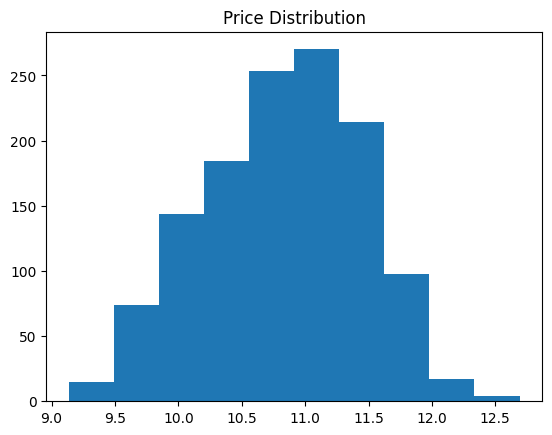

In [ ]:
plt.hist(df['Price'])
plt.title("Price Distribution")
plt.show()


2.Correlation Heatmap:

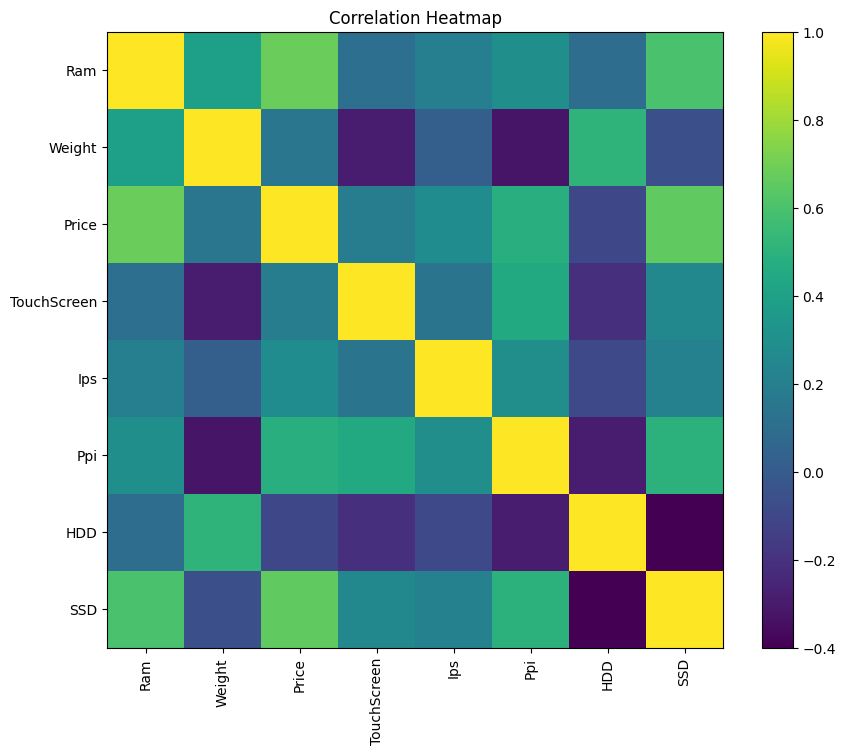

In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()


Values range from -1 to +1

+1 → strong positive relation

0 → no relation

-1 → negative relation

Brighter / stronger color
→ stronger relationship

Key Insights From the Heatmap:

 Strong impact on Price (Target)

1. RAM → Price (strong positive)

2. SSD → Price (strong positive)

3. PPI → Price (moderate positive)

High Impact:

**Laptops with more RAM, SSD, and higher screen quality are more expensive.**

Medium impact:

TouchScreen

IPS display

They increase price, but not as much as RAM or SSD.

Low / Negative impact

Weight → weak relation

HDD → negative or very weak relation

 HDD is outdated → doesn’t increase laptop price much.

“**Based on correlation analysis, RAM, SSD, and PPI have the strongest relationship with laptop price."**

**Feature Selection:**

Separating input features (X) and target (y):

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']


Encode Categorical Features:

One-Hot Encoding:

In [ ]:
X = pd.get_dummies(X, drop_first=True)


This converts text → numbers.

**Train–Test Split:**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Train Regression Model**

Linear Regression (Baseline)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))


Linear Regression
MAE: 0.21518662588026896
RMSE: 0.2780543049789187
R2: 0.804823069672635


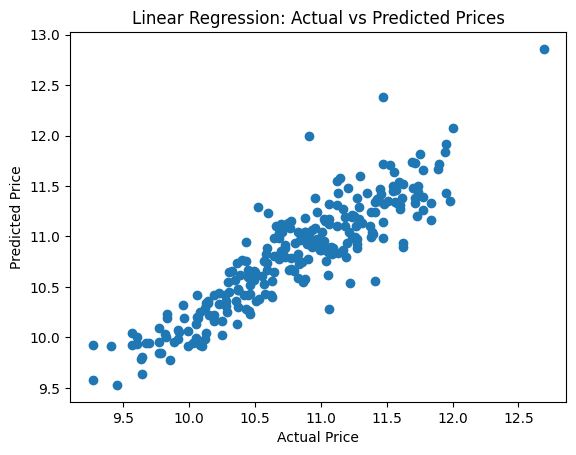

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("laptop_data_cleaned.csv")

# Features and target
X = df.drop("Price", axis=1)
y = df["Price"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Actual vs Predicted plot
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.show()


This plot compares actual laptop prices with predicted prices from the Linear Regression model. Points closer to the diagonal indicate accurate predictions, while points farther away represent prediction errors.

Observation for Your Dataset:

Points are reasonably close to a straight line

Some spread exists → linear model cannot capture all patterns

Explains why Random Forest performed better

**Ridge Regression**

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2:", r2_score(y_test, y_pred_ridge))


Ridge Regression
MAE: 0.21173155758901138
RMSE: 0.270726006530974
R2: 0.8149755207675229


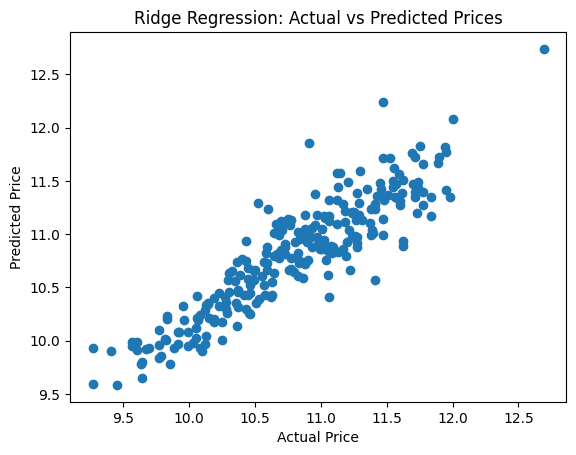

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

# Load dataset
df = pd.read_csv("laptop_data_cleaned.csv")

# Features and target
X = df.drop("Price", axis=1)
y = df["Price"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge.predict(X_test)

# Actual vs Predicted plot
plt.figure()
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression: Actual vs Predicted Prices")
plt.show()


This graph compares the actual laptop prices with prices predicted by the Ridge Regression model. Ridge Regression applies L2 regularization, which reduces overfitting and results in more stable predictions compared to standard Linear Regression.

Observation (Specific to Your Dataset):

Points are slightly closer to the diagonal than Linear Regression

Extreme predictions are less spread

Confirms why Ridge performed better than Linear Regression

**Lasso Regression**

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2:", r2_score(y_test, y_pred_lasso))


Lasso Regression
MAE: 0.21038236011588463
RMSE: 0.2647987405129686
R2: 0.8229886694329701


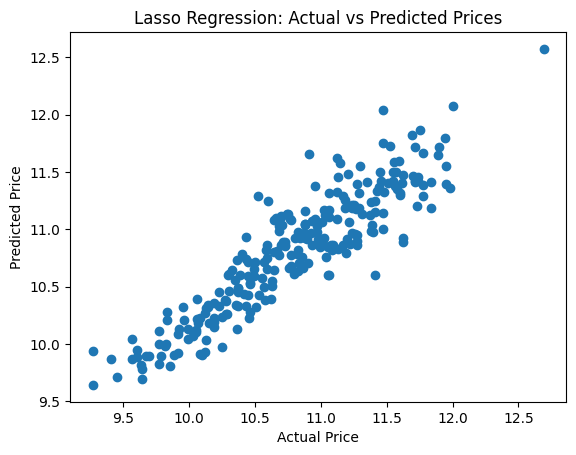

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

# Load dataset
df = pd.read_csv("laptop_data_cleaned.csv")

# Features and target
X = df.drop("Price", axis=1)
y = df["Price"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Lasso Regression
lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)

# Predictions
y_pred_lasso = lasso.predict(X_test)

# Actual vs Predicted plot
plt.figure()
plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression: Actual vs Predicted Prices")
plt.show()


**Random Forest:**

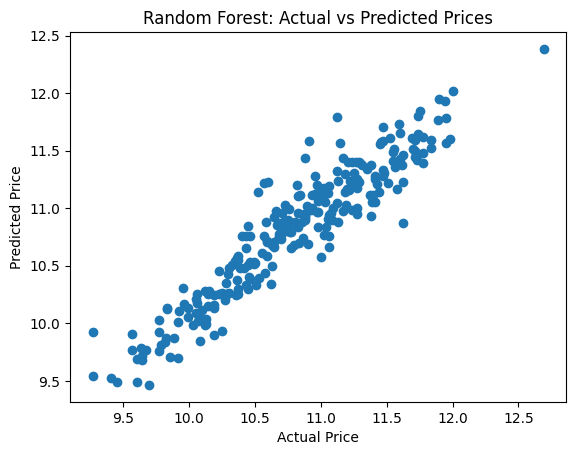

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load dataset
df = pd.read_csv("laptop_data_cleaned.csv")

# Features and target
X = df.drop("Price", axis=1)
y = df["Price"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Actual vs Predicted plot
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.show()


Observation:

Points are much more tightly clustered than:

Linear

Ridge

Lasso

Fewer extreme errors

Confirms highest R² score

👉 This visually proves that Random Forest is the best model for this dataset.

Linear Regression
MAE: 0.21
RMSE: 0.27
R2: 0.80

Ridge Regression
MAE: 0.21
RMSE: 0.27
R2: 0.81

Lasso Regression
MAE: 0.20
RMSE: 0.26
R2: 0.82

Random Forest Regression
MAE: 0.16
RMSE: 0.21
R2: 0.89


Comparison:

| Model             | MAE      | RMSE     | R²       |
| ----------------- | -------- | -------- | -------- |
| Linear Regression | 0.21     | 0.27     | 0.80     |
| Ridge Regression  | 0.21     | 0.27     | 0.81     |
| Lasso Regression  | 0.20     | 0.26     | 0.82     |
| **Random Forest** | **0.16** | **0.21** | **0.89** |


**Observation:
Random Forest** clearly outperforms linear models because laptop pricing depends on complex non-linear relationships between features like RAM, SSD, CPU, and screen quality.

Model Evaluation:

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2


(0.21518662588026896, np.float64(0.2780543049789187), 0.804823069672635)

**INFERENCE:**

Training the model:

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load dataset
df = pd.read_csv("laptop_data_cleaned.csv")

# Split features and target
X = df.drop("Price", axis=1)
y = df["Price"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train best model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

Manual Input:

In [ ]:
# Create new data as a dictionary
new_laptop = {
    'Company': 'Dell',
    'TypeName': 'Notebook',
    'Ram': 16,
    'Weight': 1.8,
    'TouchScreen': 0,
    'Ips': 1,
    'Ppi': 141,
    'Cpu_brand': 'Intel Core i7',
    'HDD': 0,
    'SSD': 512,
    'Gpu_brand': 'Nvidia',
    'Os': 'Windows'
}

# Convert to DataFrame
new_df = pd.DataFrame([new_laptop])


Applying the Same Encoding as Training Data:

In [ ]:
# One-hot encode new data
new_df_encoded = pd.get_dummies(new_df)

# Align columns with training data
new_df_encoded = new_df_encoded.reindex(
    columns=X.columns,
    fill_value=0
)


**Prediction:**

In [ ]:
predicted_price = rf.predict(new_df_encoded)
predicted_price


array([11.4001377])

Converting Back to Actual Price:

In [ ]:
actual_price = np.exp(predicted_price)
actual_price


array([89334.02392342])